In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Klasterovanje multimodalnih senzorskih podataka na MEx skupu podataka

Ovaj projekat se bavi klasterovanjem multimodalnih senzorskih podataka prikupljenih tokom izvođenja fizioterapeutskih vežbi. Cilj je grupisati sesije vežbanja na osnovu senzorskih signala i evaluirati da li se dobijeni klasteri poklapaju sa stvarnim tipovima vežbi.

## O MEx skupu podataka (MEx Multi-modal Exercise Dataset)

MEx skup podataka sadrži multimodalne zapise **7 različitih fizioterapeutskih vežbi** koje je izvodilo **30 subjekata**. Svaka vežba je izvođena u trajanju od maksimalno 60 sekundi.

### Korišćeni senzori
1.  **Axivity AX3 3-Axis Logging Accelerometer (na butini - `act`):** 
2.  **Axivity AX3 3-Axis Logging Accelerometer (na ručnom zglobu - `acw`):**
3.  **Sensing Tex Pressure Mat (prostirka pritiska - `pm`):**
4.  **Obbrec Astra Depth Camera (dubinska kamera - `dc`):**

###  Postavka senzora tokom vežbanja
Subjekti su izvodili sve vežbe u ležećem položaju na prostirci pritiska. Dubinska kamera je bila postavljena iznad njih (snimajući iz ptičje perspektive), okrenuta nadole i poravnata sa gornjom ivicom prostirke pritiska i ramenima subjekta (tako da lice subjekta ne bude snimljeno radi očuvanja privatnosti).



U ovom koraku pretražujemo fajl-sistem i mapiramo sve dostupne sesije snimanja analizirajući nazive CSV fajlova na putanji `mex/data/act`. 

Kao rezultat dobijamo listu `metadata` koja sadrži torke u formatu `(Subject, Exercise, Trial)` za ukupno **239 uspešno snimljenih sesija**. Svaki ispitanik je izveo po 8 sesija (7 vežbi, pri čemu se vežba 4 izvodi na dve strane tela), osim ispitanika 22 koji je uradio 7 sesija (vežbu 4 je odradio na samo jednoj strani).

**Značenje metapodataka:**
*   **Subject (Ispitanik):** Jedinstveni identifikator osobe (od `'01'` do `'30'`).
*   **Exercise (Vežba):** Tip fizioterapeutske vežbe (od `1` do `7`). Ove oznake će nam kasnije služiti kao stvarna klasa za evaluaciju uspešnosti algoritama klasterovanja.
*   **Trial (Pokušaj/Strana):** Oznaka pokušaja ili strane tela na kojoj se vežba izvodila. Za vežbe koje se izvode asimetrično (vežba 4), imamo dva pokušaja (`1` i `2`), dok ostale vežbe imaju samo po jedan pokušaj (`1`).

**Svrha ovog koraka:**
Ova lista nam služi kao indeks (mapa) celog skupa podataka.


In [94]:
import os
import glob

data_dir = "mex/data"
subjects = [f"{i:02d}" for i in range(1, 31)]

metadata = []

for s in subjects:
    accelometer_path = os.path.join(data_dir,"act",s)
    if not os.path.exists(accelometer_path):
        continue

    accelometer_files = sorted(glob.glob(os.path.join(accelometer_path, "*.csv")))
    for af in accelometer_files:
        fname = os.path.basename(af)
        parts = fname.split("_")
        ex = int(parts[0])
        trial = int(parts[2].split(".")[0])

        metadata.append((s, ex, trial))


print(f"Ukupno pronađeno sesija: {len(metadata)}")
print("Sesije prvog ispitanika (Subject, Exercise, Trial):")
for item in metadata[:8]:
    print(item)

Ukupno pronađeno sesija: 239
Sesije prvog ispitanika (Subject, Exercise, Trial):
('01', 1, 1)
('01', 2, 1)
('01', 3, 1)
('01', 4, 1)
('01', 4, 2)
('01', 5, 1)
('01', 6, 1)
('01', 7, 1)


In [95]:
data = {}

for s, ex, trial in metadata:
    act_path = os.path.join(data_dir, "act", s, f"{ex:02d}_act_{trial}.csv")
    acw_path = os.path.join(data_dir, "acw", s, f"{ex:02d}_acw_{trial}.csv")
    pm_path = os.path.join(data_dir, "pm_1.0_1.0", s, f"{ex:02d}_pm_{trial}.csv")
    dc_path = os.path.join(data_dir, "dc_0.05_0.05", s, f"{ex:02d}_dc_{trial}.csv")
    
    data[(s, ex, trial)] = {
        "act": pd.read_csv(act_path, header=None),
        "acw": pd.read_csv(acw_path, header=None),
        "pm": pd.read_csv(pm_path, header=None),
        "dc": pd.read_csv(dc_path, header=None)
    }

print(f"Podaci učitani. Učitano {len(data)} sesija")


Podaci učitani. Učitano 239 sesija


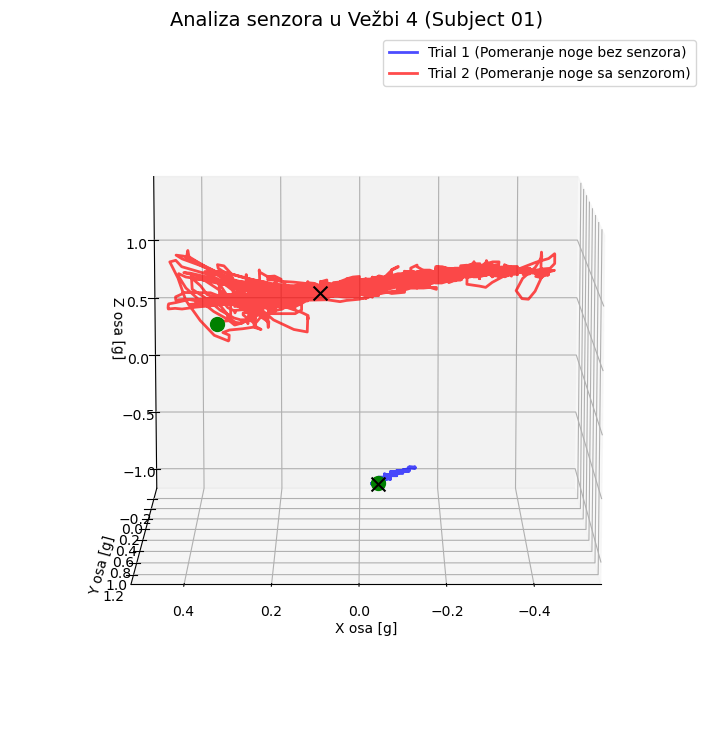

In [96]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

act_trial1 = data[("01", 4, 1)]["act"]
act_trial2 = data[("01", 4, 2)]["act"]

xs_1 = act_trial1.iloc[:, 1].values
ys_1 = act_trial1.iloc[:, 2].values
zs_1 = act_trial1.iloc[:, 3].values

xs_2 = act_trial2.iloc[:, 1].values
ys_2 = act_trial2.iloc[:, 2].values
zs_2 = act_trial2.iloc[:, 3].values

ax.plot(xs_1, ys_1, zs_1, label='Trial 1 (Pomeranje noge bez senzora)', color='blue', alpha=0.7, linewidth=2)
ax.scatter(xs_1[0], ys_1[0], zs_1[0], color='green', s=100, marker='o') 
ax.scatter(xs_1[-1], ys_1[-1], zs_1[-1], color='black', s=100, marker='x') 

ax.plot(xs_2, ys_2, zs_2, label='Trial 2 (Pomeranje noge sa senzorom)', color='red', alpha=0.7, linewidth=2)
ax.scatter(xs_2[0], ys_2[0], zs_2[0], color='green', s=100, marker='o') 
ax.scatter(xs_2[-1], ys_2[-1], zs_2[-1], color='black', s=100, marker='x') 
ax.view_init(elev=10, azim=90)
ax.set_title("Analiza senzora u Vežbi 4 (Subject 01)", fontsize=14)
ax.set_xlabel("X osa [g]")
ax.set_ylabel("Y osa [g]")
ax.set_zlabel("Z osa [g]")
ax.legend()
plt.show()

Prikaz pomeranja noge tokom izvođenja vežbe 4 (2 puta)
*   **Trial 1 (plava linija):** Ispitanik pomera "slobodnu" nogu. Noga sa senzorom leži na podu, pa senzor beleži samo gravitaciju ($Z \approx -1g$).
*   **Trial 2 (crvena linija):** Ispitanik podiže nogu na kojoj se nalazi senzor, pa on beleži pun luk pokreta u prostoru.


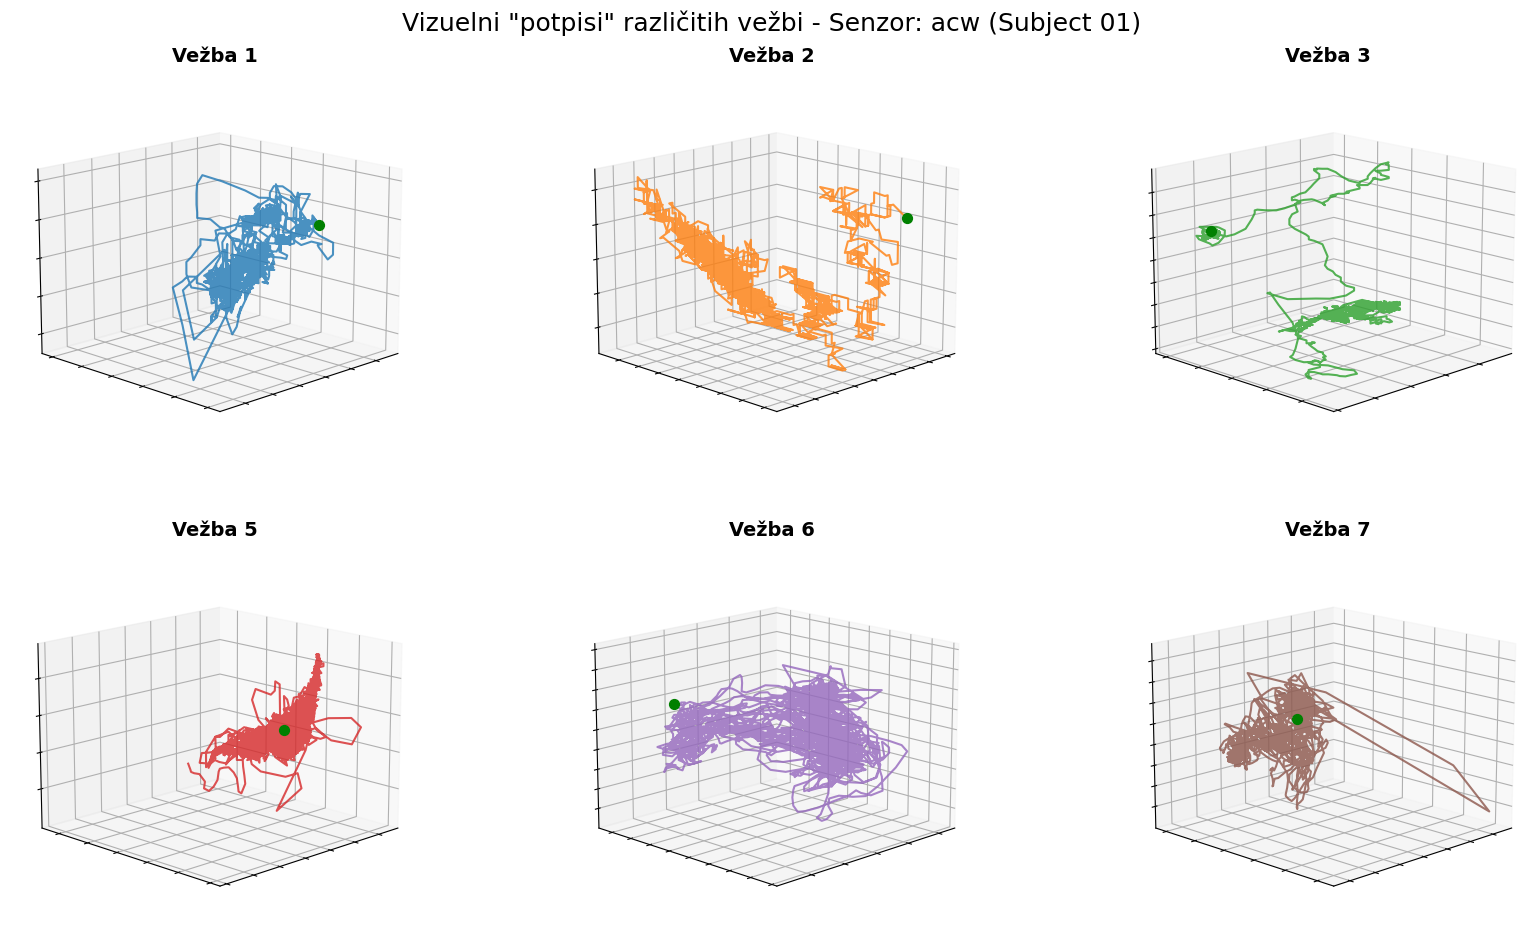

In [97]:
fig = plt.figure(figsize=(18, 10))
exercises = [1, 2, 3, 5, 6, 7]
sensor = "acw"

fig.suptitle(f"Vizuelni \"potpisi\" različitih vežbi - Senzor: {sensor} (Subject 01)", fontsize=18, y=0.98)

for i, ex in enumerate(exercises):
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    
    df = data[("01", ex, 1)][sensor]
    
    xs = df.iloc[:, 1].values
    ys = df.iloc[:, 2].values
    zs = df.iloc[:, 3].values
    
    ax.plot(xs, ys, zs, color=plt.cm.tab10(i), alpha=0.8, linewidth=1.5)
    ax.scatter(xs[0], ys[0], zs[0], color='green', s=50, marker='o') 
    
    ax.view_init(elev=15, azim=45)
    ax.set_title(f"Vežba {ex}", fontsize=14, fontweight='bold')
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

plt.subplots_adjust(top=0.92, bottom=0.05, left=0.05, right=0.95, wspace=0.1, hspace=0.2)
plt.show()



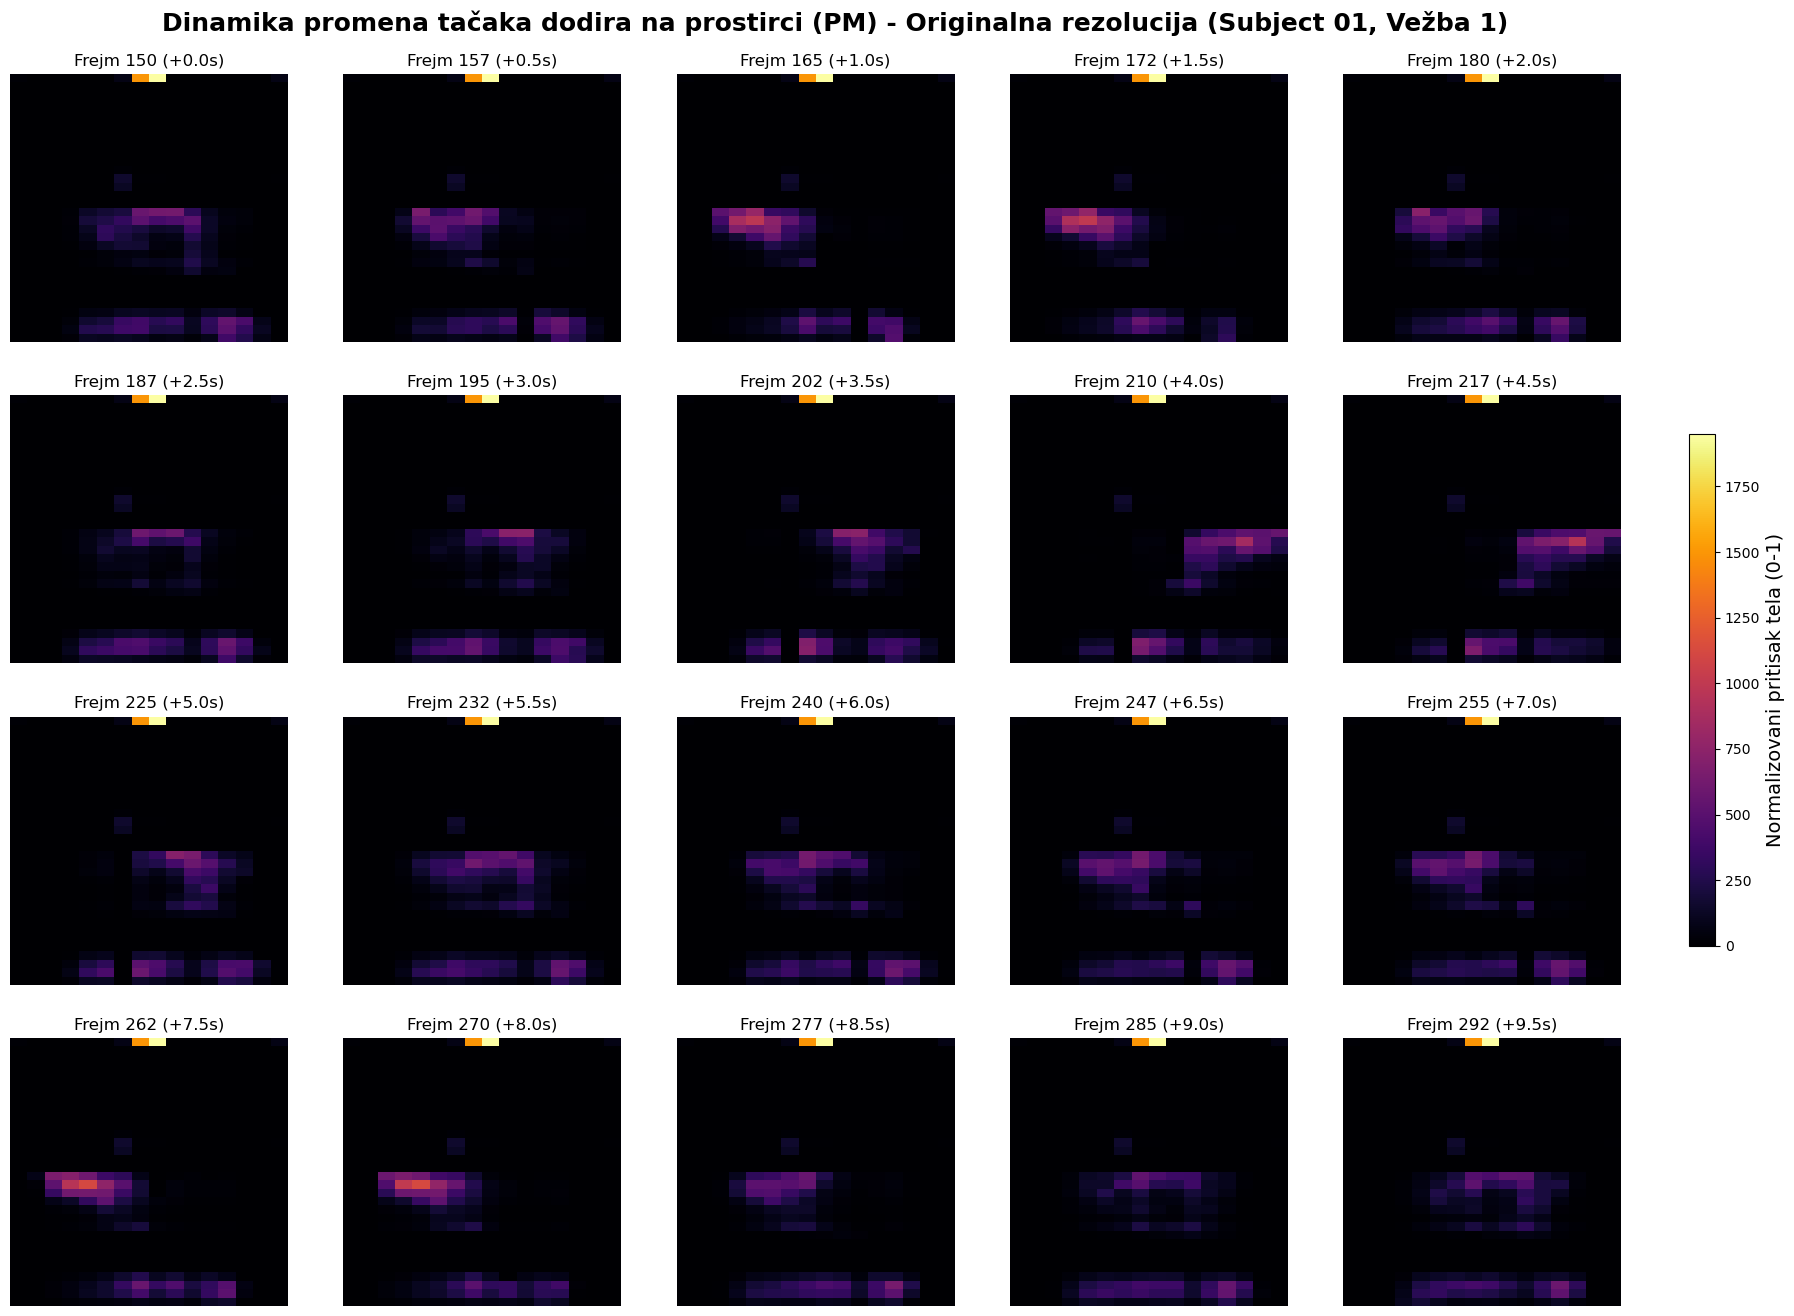

In [98]:
fig, axs = plt.subplots(4, 5, figsize=(22, 16)) 
axs = axs.flatten()

start_frame = 150
frames = [start_frame + int(i * 7.5) for i in range(20)]

pm_df = data[("01", 1, 1)]["pm"]

for i, f_idx in enumerate(frames):
    pm_frame = pm_df.iloc[f_idx, 1:].values.astype(float)
    pm_matrix = pm_frame.reshape(32, 16)
    
    im = axs[i].imshow(pm_matrix, cmap="inferno", aspect="auto")
    
    time_sec = i * 0.5
    axs[i].set_title(f"Frejm {f_idx} (+{time_sec:.1f}s)", fontsize=12)
    axs[i].axis('off') 

cbar = fig.colorbar(im, ax=axs.tolist(), fraction=0.015, pad=0.04)
cbar.set_label("Normalizovani pritisak tela (0-1)", size=14)

plt.suptitle("Dinamika promena tačaka dodira na prostirci (PM) - Originalna rezolucija (Subject 01, Vežba 1)", fontsize=18, fontweight='bold', y=0.92)
plt.show()


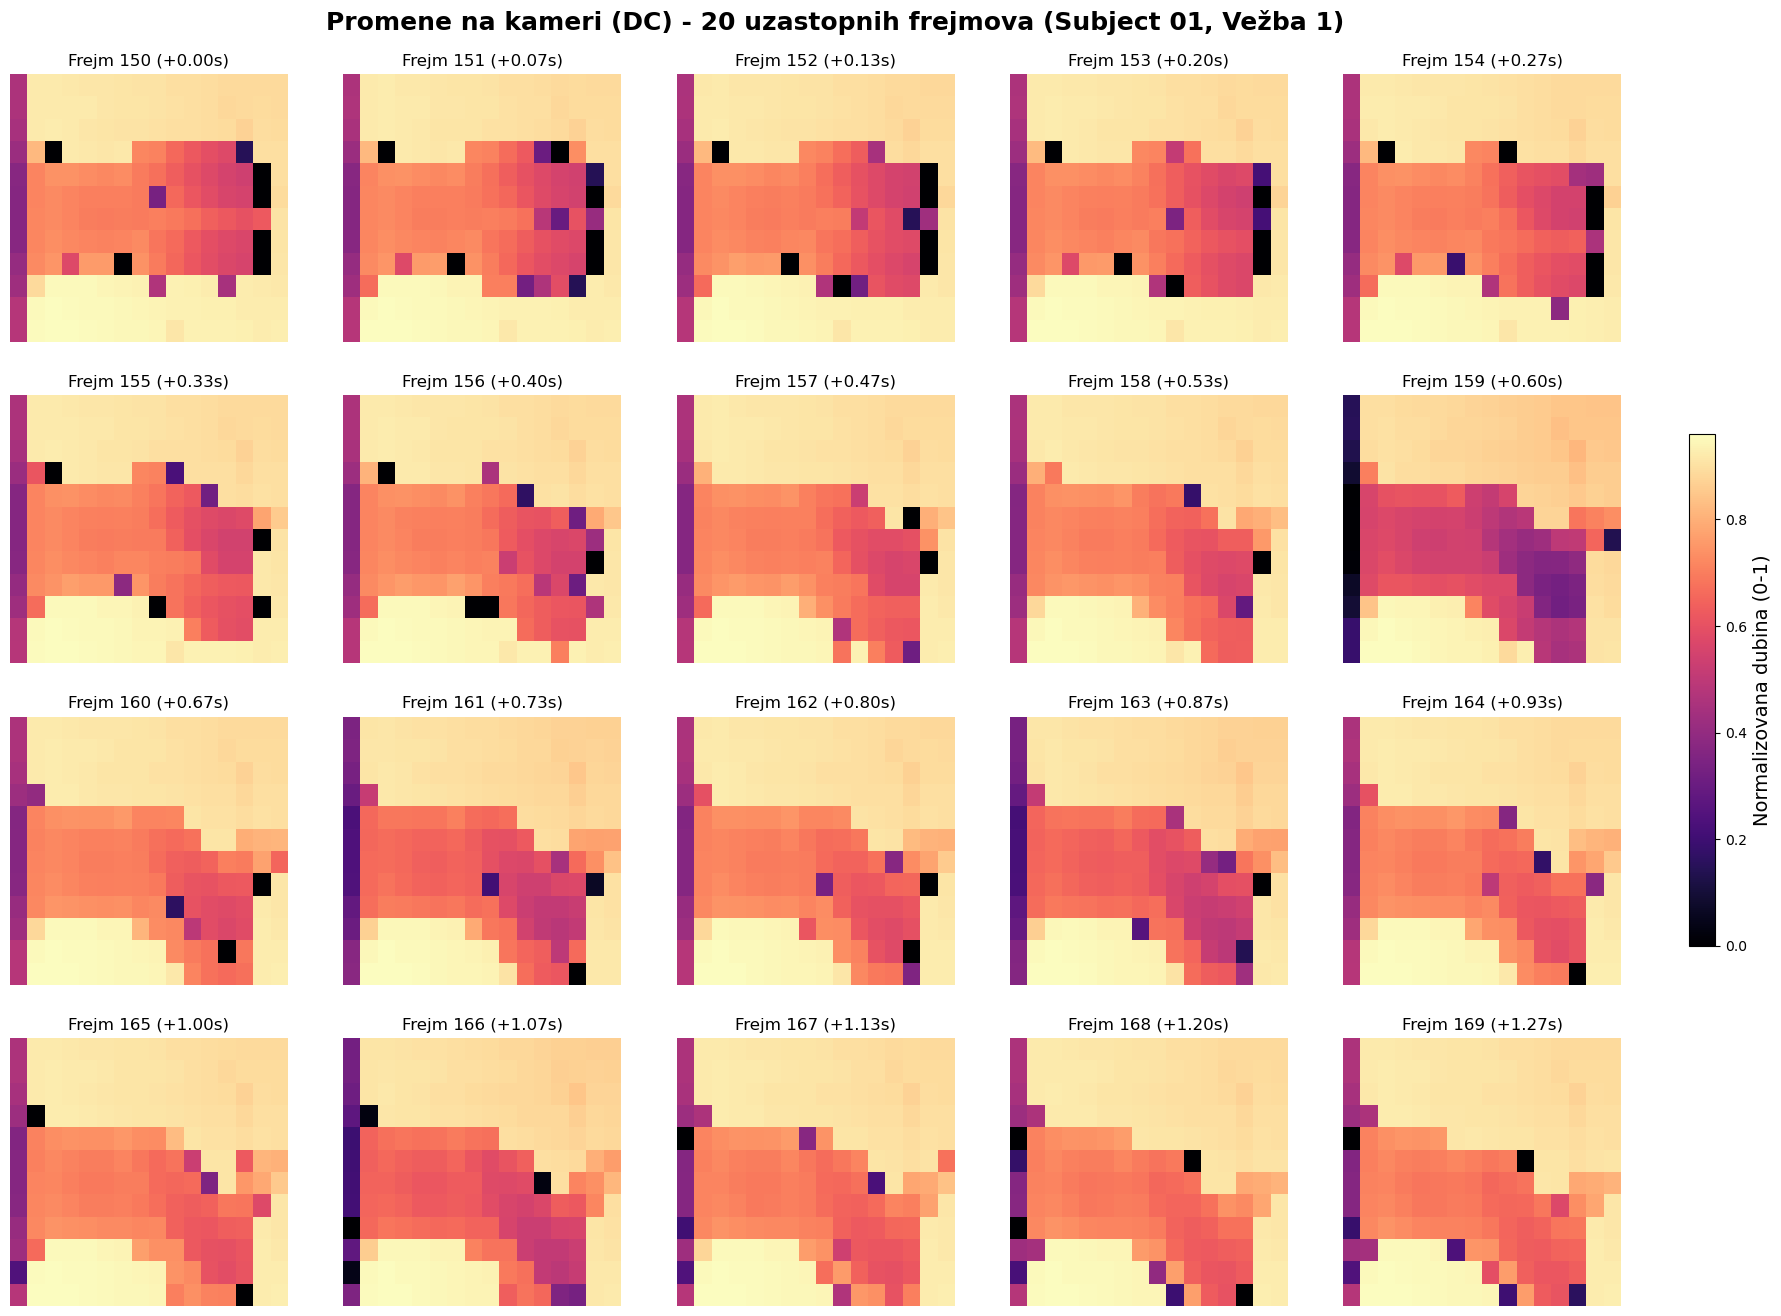

In [99]:
fig, axs = plt.subplots(4, 5, figsize=(22, 16)) 
axs = axs.flatten()

start_frame = 150
frames = [start_frame + i for i in range(20)]

dc_df = data[("01", 1, 1)]["dc"]

for i, f_idx in enumerate(frames):
    dc_frame = dc_df.iloc[f_idx, 1:].values.astype(float)
    dc_matrix = dc_frame.reshape(12, 16)
    
    im = axs[i].imshow(dc_matrix, cmap="magma", aspect="auto")
    
    time_sec = i * (1/15)
    axs[i].set_title(f"Frejm {f_idx} (+{time_sec:.2f}s)", fontsize=12)
    axs[i].axis('off') 

cbar = fig.colorbar(im, ax=axs.tolist(), fraction=0.015, pad=0.04)
cbar.set_label("Normalizovana dubina (0-1)", size=14)

plt.suptitle("Promene na kameri (DC) - 20 uzastopnih frejmova (Subject 01, Vežba 1)", fontsize=18, fontweight='bold', y=0.92)
plt.show()



### Preprocesiranje podataka

Preprocesiranje obuhvata čišćenje šuma i popunjavanje nedostajućih vrednosti, PCA redukciju visokodimenzionalnih podataka sa kamere i prostirke na 15 glavnih komponenti, kao i ekstrakciju statističkih obeležja (srednja vrednost, standardna devijacija, minimum i maksimum) čime se sve vremenske serije prevode u vektore fiksne dužine. Na samom kraju, vrši se globalna *Z-score* standardizacija celokupne matrice obeležja, kako bi se eliminisale razlike u mernim opsezima različitih senzora i podaci pripremili za algoritme klasterovanja.



In [100]:
from sklearn.preprocessing import StandardScaler

data_cleaned = {}

for key in data.keys():
    data_cleaned[key] = {}
    
    for sensor in ['act', 'acw']:
        df = data[key][sensor].copy()
        sensor_cols = [1, 2, 3]
        df[sensor_cols] = df[sensor_cols].interpolate(method='linear', limit_direction='both')
        df[sensor_cols] = df[sensor_cols].rolling(window=5, min_periods=1).mean()
        df[sensor_cols] = df[sensor_cols].bfill() 
        data_cleaned[key][sensor] = df
        
    for sensor in ['pm', 'dc']:
        df = data[key][sensor].copy()
        feature_cols = df.columns[1:]
        df[feature_cols] = df[feature_cols].fillna(0)
        data_cleaned[key][sensor] = df


In [101]:
from sklearn.decomposition import PCA
n_comp = 15

all_pm_data = pd.concat([data_cleaned[k]['pm'].iloc[:, 1:] for k in data_cleaned.keys()], ignore_index=True)
all_dc_data = pd.concat([data_cleaned[k]['dc'].iloc[:, 1:] for k in data_cleaned.keys()], ignore_index=True)

pca_pm = PCA(n_components=n_comp).fit(all_pm_data)
pca_dc = PCA(n_components=n_comp).fit(all_dc_data)
del all_pm_data, all_dc_data 

data_preprocessed = {}
for key in data_cleaned.keys():
    data_preprocessed[key] = {}
    
    data_preprocessed[key]['act'] = data_cleaned[key]['act']
    data_preprocessed[key]['acw'] = data_cleaned[key]['acw']
    
    for sensor, pca_model in zip(['pm', 'dc'], [pca_pm, pca_dc]):
        timestamp = data_cleaned[key][sensor].iloc[:, 0].values 
        reduced = pca_model.transform(data_cleaned[key][sensor].iloc[:, 1:]) 
        data_preprocessed[key][sensor] = pd.DataFrame(np.column_stack((timestamp, reduced)))



### Čuvanje preprocesiranih podataka
U ovom koraku vršimo čuvanje svih preprocesiranih podataka na disk. Svi obrađeni podaci iz memorije (uključujući i senzore visoke dimenzionalnosti svedene pomoću PCA na 15 komponenti) se eksportuju u novi direktorijum `preprocessed_mex`, uz zadržavanje originalne hijerarhije foldera i naziva fajlova.


In [102]:
output_dir = "preprocessed_mex"

for key in data_preprocessed.keys():
    s, ex, trial = key
    
    for sensor in ['act', 'acw', 'pm', 'dc']:
        sensor_dir = os.path.join(output_dir, sensor, s)
        os.makedirs(sensor_dir, exist_ok=True)
        
        file_path = os.path.join(sensor_dir, f"{ex:02d}_{sensor}_{trial}.csv")
        data_preprocessed[key][sensor].to_csv(file_path, header=False, index=False)


In [ ]:
features_list_advanced = []
labels_list = []

for key in data_preprocessed.keys():
    s, ex, trial = key
    session_features = []
    
    for sensor in ['act', 'acw', 'pm', 'dc']:
        sensor_data = data_preprocessed[key][sensor].iloc[:, 1:].values.astype(float)
        
        means = np.mean(sensor_data, axis=0)
        stds = np.std(sensor_data, axis=0)
        mins = np.min(sensor_data, axis=0)
        maxs = np.max(sensor_data, axis=0)

        session_features.extend(means)
        session_features.extend(stds)
        session_features.extend(mins)
        session_features.extend(maxs)
        
    features_list_advanced.append(session_features)
    labels_list.append(ex) 

X_raw_adv = np.array(features_list_advanced)
y = np.array(labels_list)

scaler = StandardScaler()
X_adv = scaler.fit_transform(X_raw_adv)


Izvučena obeležja! Dimenzija X_raw_adv matrice je: (239, 144)


### Primena i evaluacija algoritama klasterovanja

U ovom, finalnom koraku, vršimo testiranje i poređenje **pet različitih algoritama nenadgledanog mašinskog učenja** nad našom konačnom matricom obeležja (`X_adv`). 

S obzirom na to da MEx skup podataka sadrži tačno 7 fizioterapeutskih vežbi, za sve algoritme je broj klastera fiksiran na **7** (`n_clusters=7`). Naš cilj je da vidimo koji algoritam može najuspešnije da "prepozna" strukturu ovih 7 vežbi samo na osnovu senzorskih podataka, bez da unapred "zna" koja je vežba u pitanju.

Algoritmi koji se testiraju su:
1. **K-Means** (Klasično centroidno klasterovanje)
2. **Agglomerative Clustering** (Hijerarhijsko klasterovanje)
3. **Spectral Clustering** (Klasterovanje zasnovano na teoriji grafova)
4. **Gaussian Mixture Model (GMM)** (Verovatnosno klasterovanje na bazi Gausovih raspodela)
5. **Birch** (Algoritam dizajniran za velike skupove podataka koji gradi stablo obeležja)

**Metrike za evaluaciju:**
Kako bismo objektivno uporedili algoritme, za svaki od njih računamo dve metrike:
*   **Silhouette Score:** *Interna metrika* koja meri koliko su klasteri dobro grupisani i prostorno razdvojeni jedni od drugih. Vrednosti idu od -1 do 1 (više je bolje).
*   **Adjusted Rand Index (ARI - Poklapanje):** *Eksterna metrika* koja nam govori koliko se naši predviđeni klasteri zapravo poklapaju sa stvarnim oznakama vežbi (`y`). Vrednost 1 označava savršeno poklapanje, dok vrednost oko 0 označava nasumično grupisanje. S obzirom da radimo klasterovanje na podacima sa poznatim stvarnim klasama, **ARI nam je glavni pokazatelj uspešnosti.**


In [104]:
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

algorithms = {
    "K-Means": KMeans(n_clusters=7, random_state=42, n_init=10),
    "Agglomerative Clustering": AgglomerativeClustering(n_clusters=7),
    "Spectral Clustering": SpectralClustering(n_clusters=7, random_state=42, affinity='nearest_neighbors'),
    "Gaussian Mixture Model": GaussianMixture(n_components=7, random_state=42),
    "Birch": Birch(n_clusters=7)
}

results = []

for name, algo in algorithms.items():
    labels = algo.fit_predict(X_adv)
    
    sil = silhouette_score(X_adv, labels)
    ari = adjusted_rand_score(y, labels)
    
    results.append({
        "Algoritam": name,
        "Silhouette Score": round(sil, 4),
        "ARI (Poklapanje)": round(ari, 4),
    })

df_results = pd.DataFrame(results).sort_values(by="ARI (Poklapanje)", ascending=False).reset_index(drop=True)
print(df_results)


                  Algoritam  Silhouette Score  ARI (Poklapanje)
0       Spectral Clustering            0.0779            0.6095
1                   K-Means            0.0817            0.5427
2  Agglomerative Clustering            0.0723            0.5076
3                     Birch            0.0723            0.5076
4    Gaussian Mixture Model            0.0906            0.3733


Da bismo utvrdili koji senzori najviše doprinose klasterovanju, koristeći `itertools.combinations` generišemo sve kombinacije od 2 ili 3 senzora iz skupa od 4 i na svaku primenjujemo istih 5 algoritama. Rezultate zatim objedinjujemo sa rezultatima za sva 4 senzora i sortiramo po ARI vrednosti kako bismo identifikovali optimalnu kombinaciju.


In [105]:
from itertools import combinations

all_sensors = ['act', 'acw', 'pm', 'dc']
subsets = list(combinations(all_sensors, 2)) + list(combinations(all_sensors, 3))
results = []


In [106]:
algorithms = {
    "K-Means": KMeans(n_clusters=7, random_state=42, n_init=10),
    "Agglomerative Clustering": AgglomerativeClustering(n_clusters=7),
    "Spectral Clustering": SpectralClustering(n_clusters=7, random_state=42, affinity='nearest_neighbors'),
    "Gaussian Mixture Model": GaussianMixture(n_components=7, random_state=42),
    "Birch": Birch(n_clusters=7)
}


for subset in subsets:
    
    features_list_advanced = []
    labels_list = []
    
    for key in data_preprocessed.keys():
        s, ex, trial = key
        session_features = []
        
        for sensor in subset: 
            sensor_data = data_preprocessed[key][sensor].iloc[:, 1:].values.astype(float)
            
            means = np.mean(sensor_data, axis=0)
            stds = np.std(sensor_data, axis=0)
            mins = np.min(sensor_data, axis=0)
            maxs = np.max(sensor_data, axis=0)
            
            session_features.extend(means)
            session_features.extend(stds)
            session_features.extend(mins)
            session_features.extend(maxs)
            
        features_list_advanced.append(session_features)
        labels_list.append(ex)
        
    X_raw_adv = np.array(features_list_advanced)
    y = np.array(labels_list)
    
    scaler = StandardScaler()
    X_adv = scaler.fit_transform(X_raw_adv)
    
    for name, algo in algorithms.items():
        labels = algo.fit_predict(X_adv)
        
        ari = adjusted_rand_score(y, labels)
        sil = silhouette_score(X_adv, labels)
        
        results.append({
            "Algoritam": name,
            "Silhouette Score": round(sil, 4),
            "Uključeni senzori": ", ".join(subset),
            "ARI (Poklapanje)": round(ari, 4)
        })



In [107]:
df_subset_results = pd.DataFrame(results)

df_results["Uključeni senzori"] = "act, acw, pm, dc"

df_combined = pd.concat([df_results, df_subset_results], ignore_index=True)

df_combined = df_combined.sort_values(by="ARI (Poklapanje)", ascending=False).reset_index(drop=True)

display(df_combined.head(5))


,Algoritam,Silhouette Score,ARI (Poklapanje),Uključeni senzori
0,Spectral Clustering,0.0794,0.6219,"act, pm, dc"
1,Birch,0.0731,0.6202,"pm, dc"
2,Agglomerative Clustering,0.0731,0.6202,"pm, dc"
3,Spectral Clustering,0.0779,0.6095,"act, acw, pm, dc"
4,Agglomerative Clustering,0.0788,0.6084,"act, pm, dc"


### Napredna ekstrakcija obeležja (Srednja vrednost, Standardna devijacija, RMS, Raspon)

Kako bismo dodatno poboljšali rezultate klasterovanja bez prevelike složenosti, pored osnovnih statističkih obeležja uvode se **RMS (Root Mean Square)** kao mera snage signala i **raspon (peak-to-peak amplitude)** kao mera dinamičkog opsega pokreta.

Ova obeležja primenjujemo selektivno:
* Za akcelerometre (`act` i `acw`) računamo **srednju vrednost, standardnu devijaciju, RMS i raspon (ptp)**.
* Za prostirku (`pm`) i dubinsku kameru (`dc`) računamo samo **srednju vrednost i standardnu devijaciju** (kako bismo izbegli preveliku dimenzionalnost i šum).

In [108]:
def extract_features(sensor_data, include_advanced=True):
    data = sensor_data
    means = np.mean(data, axis=0)
    stds = np.std(data, axis=0)
    features = list(means) + list(stds)
    if include_advanced:
        rms = np.sqrt(np.mean(data**2, axis=0))
        ptps = np.ptp(data, axis=0)
        features.extend(rms)
        features.extend(ptps)
    return features

In [109]:
features_list_advanced = []
labels_list = []

for key in data_preprocessed.keys():
    s, ex, trial = key
    session_features = []
    for sensor in ['act', 'acw', 'pm', 'dc']:
        sensor_data = data_preprocessed[key][sensor].iloc[:, 1:].values.astype(float)
        use_adv = (sensor in ['act', 'acw'])
        session_features.extend(extract_features(sensor_data, include_advanced=use_adv))
    features_list_advanced.append(session_features)
    labels_list.append(ex)

X_raw_adv = np.array(features_list_advanced)
y = np.array(labels_list)

scaler = StandardScaler()
X_adv = scaler.fit_transform(X_raw_adv)

algorithms = {
    "K-Means": KMeans(n_clusters=7, random_state=42, n_init=10),
    "Agglomerative Clustering": AgglomerativeClustering(n_clusters=7),
    "Spectral Clustering": SpectralClustering(n_clusters=7, random_state=42, affinity='nearest_neighbors'),
    "Gaussian Mixture Model": GaussianMixture(n_components=7, random_state=42),
    "Birch": Birch(n_clusters=7)
}

results_adv = []

for name, algo in algorithms.items():
    labels = algo.fit_predict(X_adv)
    sil = silhouette_score(X_adv, labels)
    ari = adjusted_rand_score(y, labels)
    results_adv.append({
        "Algoritam": name,
        "Silhouette Score": round(sil, 4),
        "ARI (Poklapanje)": round(ari, 4),
    })

df_results_adv = pd.DataFrame(results_adv).sort_values(by="ARI (Poklapanje)", ascending=False).reset_index(drop=True)
print(df_results_adv)

                  Algoritam  Silhouette Score  ARI (Poklapanje)
0  Agglomerative Clustering            0.1101            0.8169
1                     Birch            0.1101            0.8169
2                   K-Means            0.1065            0.7077
3       Spectral Clustering            0.1041            0.6719
4    Gaussian Mixture Model            0.1092            0.6264


### Pretraga podskupova senzora sa proširenim pojednostavljenim obeležjima

Ponavljamo analizu kombinacija senzora koristeći prošireni pojednostavljeni skup obeležja.

In [117]:
results_comb_adv = []

for subset in subsets:
    features_list_advanced = []
    labels_list = []
    for key in data_preprocessed.keys():
        s, ex, trial = key
        session_features = []
        for sensor in subset:
            sensor_data = data_preprocessed[key][sensor].iloc[:, 1:].values.astype(float)
            use_adv = (sensor in ['act', 'acw'])
            session_features.extend(extract_features(sensor_data, include_advanced=use_adv))
        features_list_advanced.append(session_features)
        labels_list.append(ex)
    X_raw_adv = np.array(features_list_advanced)
    y = np.array(labels_list)
    X_adv = StandardScaler().fit_transform(X_raw_adv)
    for name, algo in algorithms.items():
        labels = algo.fit_predict(X_adv)
        ari = adjusted_rand_score(y, labels)
        sil = silhouette_score(X_adv, labels)
        results_comb_adv.append({
            "Algoritam": name,
            "Silhouette Score": round(sil, 4),
            "Uključeni senzori": ", ".join(subset),
            "ARI (Poklapanje)": round(ari, 4)
        })

In [118]:
df_subset_results_adv = pd.DataFrame(results_comb_adv)
df_results_adv["Uključeni senzori"] = "act, acw, pm, dc"
df_combined_adv = pd.concat([df_results_adv, df_subset_results_adv], ignore_index=True)
df_combined_adv = df_combined_adv.sort_values(by="ARI (Poklapanje)", ascending=False).reset_index(drop=True)
display(df_combined_adv.head(10))

,Algoritam,Silhouette Score,ARI (Poklapanje),Uključeni senzori
0,Gaussian Mixture Model,0.1332,0.8254,"act, acw, dc"
1,Birch,0.1101,0.8169,"act, acw, pm, dc"
2,Agglomerative Clustering,0.1101,0.8169,"act, acw, pm, dc"
3,Agglomerative Clustering,0.1366,0.7727,"act, dc"
4,Birch,0.1366,0.7727,"act, dc"
5,Agglomerative Clustering,0.1177,0.7508,"act, acw, dc"
6,Birch,0.1177,0.7508,"act, acw, dc"
7,K-Means,0.1358,0.7171,"act, acw, dc"
8,K-Means,0.1421,0.7140,"act, dc"
9,Spectral Clustering,0.1352,0.7096,"act, acw, dc"


### Čuvanje najboljih modela

U ovom koraku vršimo automatsko obučavanje i čuvanje tri najbolje ocenjena modela na osnovu rezultata iz prethodne pretrage podskupova.

Modeli se čuvaju u direktorijum `models/` pomoću biblioteke `joblib` pod nazivom koji opisuje njihov rang, primenjeni algoritam i korišćene senzore (npr. `models/gaussian_mixture_model_act_acw_dc.pkl`).

In [121]:
import joblib
import shutil

shutil.rmtree('models', ignore_errors=True)
os.makedirs('models', exist_ok=True)


algo_mapping = {
    "K-Means": lambda: KMeans(n_clusters=7, random_state=42, n_init=10),
    "Agglomerative Clustering": lambda: AgglomerativeClustering(n_clusters=7),
    "Spectral Clustering": lambda: SpectralClustering(n_clusters=7, random_state=42, affinity='nearest_neighbors'),
    "Gaussian Mixture Model": lambda: GaussianMixture(n_components=7, random_state=42),
    "Birch": lambda: Birch(n_clusters=7)
}

for rank in range(3):
    row = df_combined_adv.iloc[rank]
    algo_name = row['Algoritam']
    sensors_str = row['Uključeni senzori']
    sensors_list = [s.strip() for s in sensors_str.split(',')]
    features_list = []
    for key in data_preprocessed.keys():
        session_features = []
        for sensor in sensors_list:
            sensor_data = data_preprocessed[key][sensor].iloc[:, 1:].values.astype(float)
            use_adv = (sensor in ['act', 'acw'])
            session_features.extend(extract_features(sensor_data, include_advanced=use_adv))
        features_list.append(session_features)
    X_scaled = StandardScaler().fit_transform(np.array(features_list))
    model = algo_mapping[algo_name]()
    model.fit(X_scaled)
    safe_sensors = '_'.join(sensors_list)
    safe_algo = algo_name.replace(' ', '_').lower()
    filename = f"models/{safe_algo}_{safe_sensors}.pkl"
    joblib.dump(model, filename)

### Vizuelizacija dobijenih klastera za top 2 modela

Da bismo vizuelno procenili kvalitet klasterovanja, koristimo **Analizu glavnih komponenti (PCA)** za projektovanje visokodimenzionalnog prostora obeležja u 2D ravan.

Za svaku od dve najbolje konfiguracije prikazujemo dva uporedna grafikona:
1. Grafikon sa leve strane prikazuje tačke obojene prema **klasterima koje je predvideo model**.
2. Grafikon sa desne strane prikazuje iste tačke obojene prema **stvarnim klasama vežbi (stvarna obeležja)**.

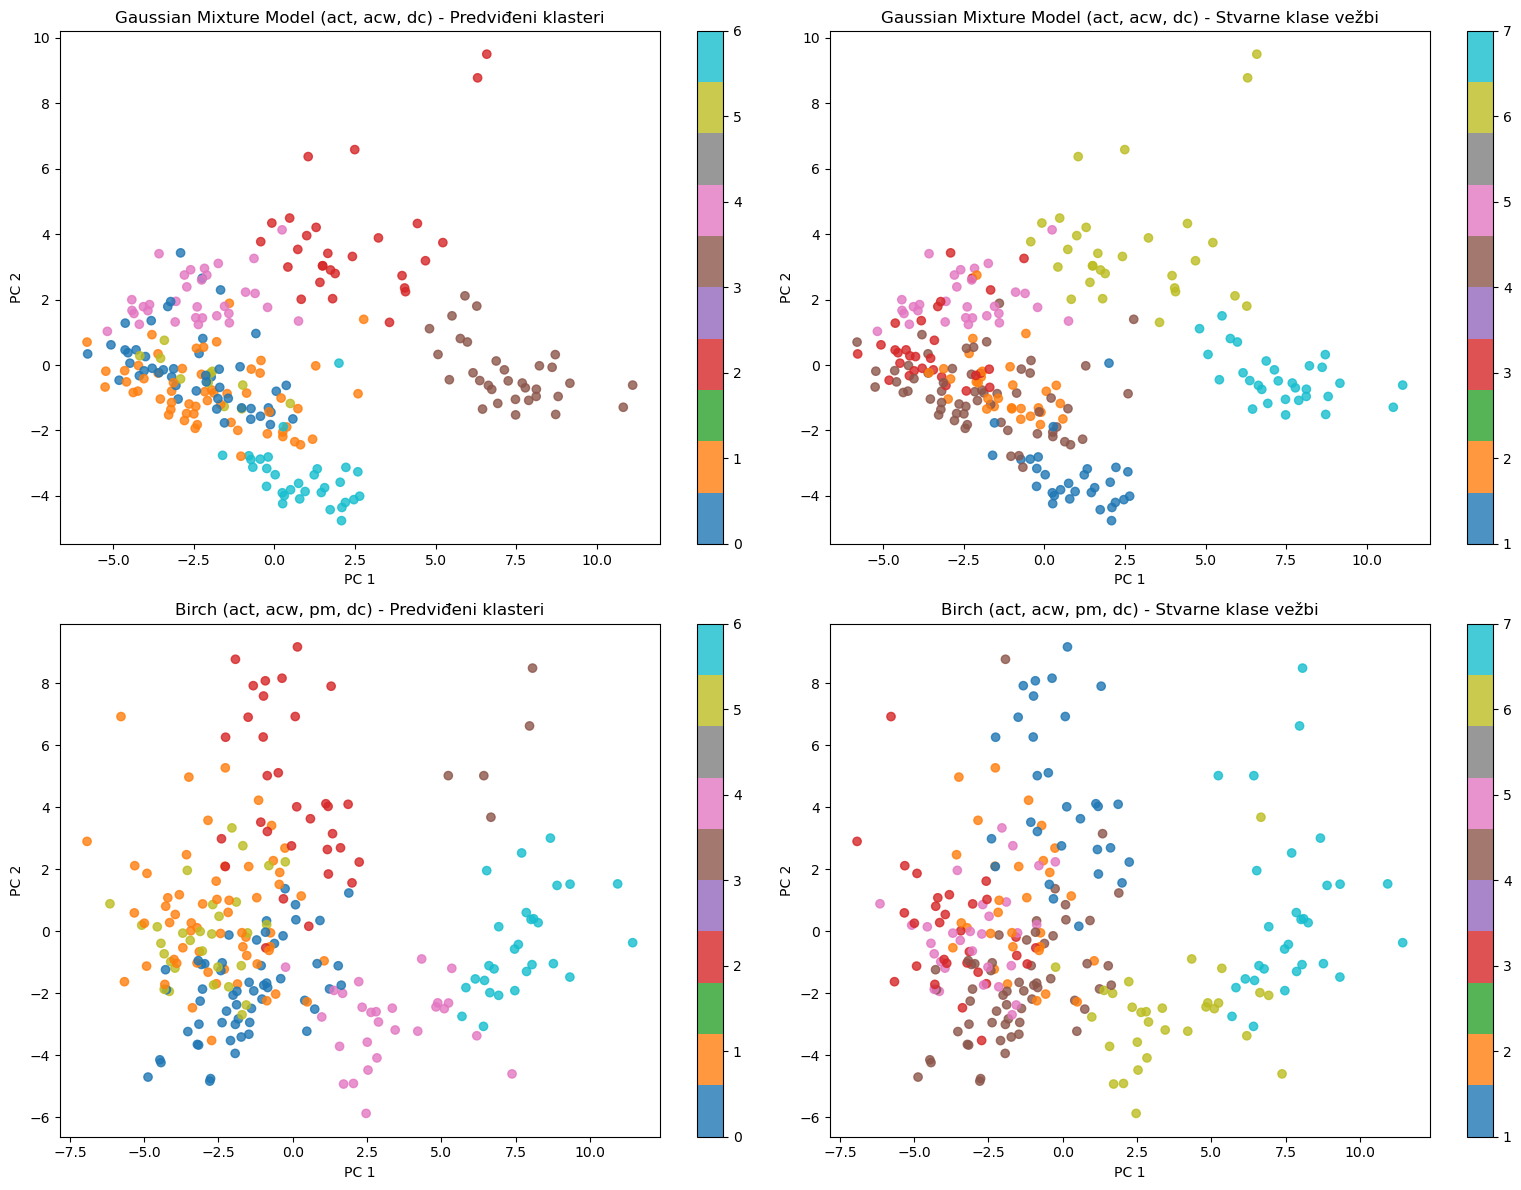

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

row_1 = df_combined_adv.iloc[0]
algo_name_1 = row_1['Algoritam']
sensors_list_1 = [s.strip() for s in row_1['Uključeni senzori'].split(',')]
features_list_1 = []
for key in data_preprocessed.keys():
    session_features = []
    for sensor in sensors_list_1:
        sensor_data = data_preprocessed[key][sensor].iloc[:, 1:].values.astype(float)
        use_adv = (sensor in ['act', 'acw'])
        session_features.extend(extract_features(sensor_data, include_advanced=use_adv))
    features_list_1.append(session_features)
X_1 = StandardScaler().fit_transform(np.array(features_list_1))
model_1 = algo_mapping[algo_name_1]()
labels_1 = model_1.fit_predict(X_1)
pca_1 = PCA(n_components=2)
X_1_2d = pca_1.fit_transform(X_1)

sc1_pred = axs[0, 0].scatter(X_1_2d[:, 0], X_1_2d[:, 1], c=labels_1, cmap='tab10', alpha=0.8)
axs[0, 0].set_title(f"{algo_name_1} ({', '.join(sensors_list_1)}) - Predviđeni klasteri")
axs[0, 0].set_xlabel("PC 1")
axs[0, 0].set_ylabel("PC 2")
fig.colorbar(sc1_pred, ax=axs[0, 0], ticks=range(7))

sc1_true = axs[0, 1].scatter(X_1_2d[:, 0], X_1_2d[:, 1], c=y, cmap='tab10', alpha=0.8)
axs[0, 1].set_title(f"{algo_name_1} ({', '.join(sensors_list_1)}) - Stvarne klase vežbi")
axs[0, 1].set_xlabel("PC 1")
axs[0, 1].set_ylabel("PC 2")
fig.colorbar(sc1_true, ax=axs[0, 1], ticks=range(1, 8))

row_2 = df_combined_adv.iloc[1]
algo_name_2 = row_2['Algoritam']
sensors_list_2 = [s.strip() for s in row_2['Uključeni senzori'].split(',')]
features_list_2 = []
for key in data_preprocessed.keys():
    session_features = []
    for sensor in sensors_list_2:
        sensor_data = data_preprocessed[key][sensor].iloc[:, 1:].values.astype(float)
        use_adv = (sensor in ['act', 'acw'])
        session_features.extend(extract_features(sensor_data, include_advanced=use_adv))
    features_list_2.append(session_features)
X_2 = StandardScaler().fit_transform(np.array(features_list_2))
model_2 = algo_mapping[algo_name_2]()
labels_2 = model_2.fit_predict(X_2)
pca_2 = PCA(n_components=2)
X_2_2d = pca_2.fit_transform(X_2)

sc2_pred = axs[1, 0].scatter(X_2_2d[:, 0], X_2_2d[:, 1], c=labels_2, cmap='tab10', alpha=0.8)
axs[1, 0].set_title(f"{algo_name_2} ({', '.join(sensors_list_2)}) - Predviđeni klasteri")
axs[1, 0].set_xlabel("PC 1")
axs[1, 0].set_ylabel("PC 2")
fig.colorbar(sc2_pred, ax=axs[1, 0], ticks=range(7))

sc2_true = axs[1, 1].scatter(X_2_2d[:, 0], X_2_2d[:, 1], c=y, cmap='tab10', alpha=0.8)
axs[1, 1].set_title(f"{algo_name_2} ({', '.join(sensors_list_2)}) - Stvarne klase vežbi")
axs[1, 1].set_xlabel("PC 1")
axs[1, 1].set_ylabel("PC 2")
fig.colorbar(sc2_true, ax=axs[1, 1], ticks=range(1, 8))

plt.tight_layout()
plt.show()